In [38]:
import fastf1
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [15]:
session = fastf1.get_session(2025, "Monaco", "R")
session.load()

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


In [16]:
session.results

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:40:33.843000,Finished,25.0,78.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:03.131000,Finished,18.0,78.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,3.0,3,3.0,NaT,NaT,NaT,0 days 00:00:03.658000,Finished,15.0,78.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,4.0,4,4.0,NaT,NaT,NaT,0 days 00:00:20.572000,Finished,12.0,78.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,5.0,5,7.0,NaT,NaT,NaT,0 days 00:00:51.387000,Finished,10.0,78.0
6,6,I HADJAR,HAD,hadjar,Racing Bulls,6C98FF,rb,Isack,Hadjar,Isack Hadjar,...,6.0,6,5.0,NaT,NaT,NaT,0 days 00:01:05.082000,Lapped,8.0,77.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,7.0,7,8.0,NaT,NaT,NaT,0 days 00:01:06.029000,Lapped,6.0,77.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,8.0,8,9.0,NaT,NaT,NaT,0 days 00:01:06.746000,Lapped,4.0,77.0
23,23,A ALBON,ALB,albon,Williams,1868DB,williams,Alexander,Albon,Alexander Albon,...,9.0,9,10.0,NaT,NaT,NaT,0 days 00:00:11.869000,Lapped,2.0,76.0
55,55,C SAINZ,SAI,sainz,Williams,1868DB,williams,Carlos,Sainz,Carlos Sainz,...,10.0,10,11.0,NaT,NaT,NaT,0 days 00:00:15.232000,Lapped,1.0,76.0


In [17]:
session.results.columns

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')

In [18]:
session.results.head()

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:40:33.843000,Finished,25.0,78.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:03.131000,Finished,18.0,78.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,3.0,3,3.0,NaT,NaT,NaT,0 days 00:00:03.658000,Finished,15.0,78.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,4.0,4,4.0,NaT,NaT,NaT,0 days 00:00:20.572000,Finished,12.0,78.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,5.0,5,7.0,NaT,NaT,NaT,0 days 00:00:51.387000,Finished,10.0,78.0


In [19]:
session.results.dtypes

DriverNumber                   object
BroadcastName                  object
Abbreviation                   object
DriverId                       object
TeamName                       object
TeamColor                      object
TeamId                         object
FirstName                      object
LastName                       object
FullName                       object
HeadshotUrl                    object
CountryCode                    object
Position                      float64
ClassifiedPosition             object
GridPosition                  float64
Q1                    timedelta64[ns]
Q2                    timedelta64[ns]
Q3                    timedelta64[ns]
Time                  timedelta64[ns]
Status                         object
Points                        float64
Laps                          float64
dtype: object

In [20]:
session.results.shape

(20, 22)

In [21]:
session.results.describe()

,Position,GridPosition,Q1,Q2,Q3,Time,Points,Laps
count,20.00000,20.00000,0,0,0,18,20.000000,20.000000
mean,10.50000,10.50000,NaT,NaT,NaT,0 days 00:06:16.323388888,5.050000,71.150000
std,5.91608,5.91608,NaT,NaT,NaT,0 days 00:23:32.174211960,7.359026,17.643472
min,1.00000,1.00000,NaT,NaT,NaT,0 days 00:00:03.131000,0.000000,7.000000
25%,5.75000,5.75000,NaT,NaT,NaT,0 days 00:00:16.567000,0.000000,76.000000
50%,10.50000,10.50000,NaT,NaT,NaT,0 days 00:00:55.903500,0.500000,76.000000
75%,15.25000,15.25000,NaT,NaT,NaT,0 days 00:01:08.004500,8.500000,77.250000
max,20.00000,20.00000,NaT,NaT,NaT,0 days 01:40:33.843000,25.000000,78.000000


In [22]:
session.results.head()

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
4,4,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,1.0,1,1.0,NaT,NaT,NaT,0 days 01:40:33.843000,Finished,25.0,78.0
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,2.0,2,2.0,NaT,NaT,NaT,0 days 00:00:03.131000,Finished,18.0,78.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,3.0,3,3.0,NaT,NaT,NaT,0 days 00:00:03.658000,Finished,15.0,78.0
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,4.0,4,4.0,NaT,NaT,NaT,0 days 00:00:20.572000,Finished,12.0,78.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,5.0,5,7.0,NaT,NaT,NaT,0 days 00:00:51.387000,Finished,10.0,78.0


In [23]:
session.results[[
    "FullName",
    "TeamName",
    "Position",
    "GridPosition",
    "Points",
    "Laps",
    "Status"
]]

,FullName,TeamName,Position,GridPosition,Points,Laps,Status
4,Lando Norris,McLaren,1.0,1.0,25.0,78.0,Finished
16,Charles Leclerc,Ferrari,2.0,2.0,18.0,78.0,Finished
81,Oscar Piastri,McLaren,3.0,3.0,15.0,78.0,Finished
1,Max Verstappen,Red Bull Racing,4.0,4.0,12.0,78.0,Finished
44,Lewis Hamilton,Ferrari,5.0,7.0,10.0,78.0,Finished
6,Isack Hadjar,Racing Bulls,6.0,5.0,8.0,77.0,Lapped
31,Esteban Ocon,Haas F1 Team,7.0,8.0,6.0,77.0,Lapped
30,Liam Lawson,Racing Bulls,8.0,9.0,4.0,77.0,Lapped
23,Alexander Albon,Williams,9.0,10.0,2.0,76.0,Lapped
55,Carlos Sainz,Williams,10.0,11.0,1.0,76.0,Lapped


In [24]:
session.results[[
    "FullName",
    "Q1",
    "Q2",
    "Q3",
    "Time"
]]

,FullName,Q1,Q2,Q3,Time
4,Lando Norris,NaT,NaT,NaT,0 days 01:40:33.843000
16,Charles Leclerc,NaT,NaT,NaT,0 days 00:00:03.131000
81,Oscar Piastri,NaT,NaT,NaT,0 days 00:00:03.658000
1,Max Verstappen,NaT,NaT,NaT,0 days 00:00:20.572000
44,Lewis Hamilton,NaT,NaT,NaT,0 days 00:00:51.387000
6,Isack Hadjar,NaT,NaT,NaT,0 days 00:01:05.082000
31,Esteban Ocon,NaT,NaT,NaT,0 days 00:01:06.029000
30,Liam Lawson,NaT,NaT,NaT,0 days 00:01:06.746000
23,Alexander Albon,NaT,NaT,NaT,0 days 00:00:11.869000
55,Carlos Sainz,NaT,NaT,NaT,0 days 00:00:15.232000


In [25]:
results = session.results.copy()

results["PositionsGained"] = (
    results["GridPosition"] - results["Position"]
)

In [26]:
results[[
    "FullName",
    "GridPosition",
    "Position",
    "PositionsGained"
]]

,FullName,GridPosition,Position,PositionsGained
4,Lando Norris,1.0,1.0,0.0
16,Charles Leclerc,2.0,2.0,0.0
81,Oscar Piastri,3.0,3.0,0.0
1,Max Verstappen,4.0,4.0,0.0
44,Lewis Hamilton,7.0,5.0,2.0
6,Isack Hadjar,5.0,6.0,-1.0
31,Esteban Ocon,8.0,7.0,1.0
30,Liam Lawson,9.0,8.0,1.0
23,Alexander Albon,10.0,9.0,1.0
55,Carlos Sainz,11.0,10.0,1.0


In [27]:
results.sort_values("PositionsGained", ascending=False)

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps,PositionsGained
87,87,O BEARMAN,BEA,bearman,Haas F1 Team,9C9FA2,haas,Oliver,Bearman,Oliver Bearman,...,12,20.0,NaT,NaT,NaT,0 days 00:00:54.693000,Lapped,0.0,76.0,8.0
43,43,F COLAPINTO,COL,colapinto,Alpine,00A1E8,alpine,Franco,Colapinto,Franco Colapinto,...,13,18.0,NaT,NaT,NaT,0 days 00:00:57.114000,Lapped,0.0,76.0,5.0
18,18,L STROLL,STR,stroll,Aston Martin,229971,aston_martin,Lance,Stroll,Lance Stroll,...,15,19.0,NaT,NaT,NaT,0 days 00:01:10.395000,Lapped,0.0,76.0,4.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,11,14.0,NaT,NaT,NaT,0 days 00:00:33.844000,Lapped,0.0,76.0,3.0
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,5,7.0,NaT,NaT,NaT,0 days 00:00:51.387000,Finished,10.0,78.0,2.0
5,5,G BORTOLETO,BOR,bortoleto,Kick Sauber,01C00E,sauber,Gabriel,Bortoleto,Gabriel Bortoleto,...,14,16.0,NaT,NaT,NaT,0 days 00:01:08.424000,Lapped,0.0,76.0,2.0
55,55,C SAINZ,SAI,sainz,Williams,1868DB,williams,Carlos,Sainz,Carlos Sainz,...,10,11.0,NaT,NaT,NaT,0 days 00:00:15.232000,Lapped,1.0,76.0,1.0
31,31,E OCON,OCO,ocon,Haas F1 Team,9C9FA2,haas,Esteban,Ocon,Esteban Ocon,...,7,8.0,NaT,NaT,NaT,0 days 00:01:06.029000,Lapped,6.0,77.0,1.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,8,9.0,NaT,NaT,NaT,0 days 00:01:06.746000,Lapped,4.0,77.0,1.0
23,23,A ALBON,ALB,albon,Williams,1868DB,williams,Alexander,Albon,Alexander Albon,...,9,10.0,NaT,NaT,NaT,0 days 00:00:11.869000,Lapped,2.0,76.0,1.0


In [28]:
results.sort_values(
    "PositionsGained",
    ascending=False
)[[
    "FullName",
    "TeamName",
    "GridPosition",
    "Position",
    "PositionsGained"
]]

,FullName,TeamName,GridPosition,Position,PositionsGained
87,Oliver Bearman,Haas F1 Team,20.0,12.0,8.0
43,Franco Colapinto,Alpine,18.0,13.0,5.0
18,Lance Stroll,Aston Martin,19.0,15.0,4.0
63,George Russell,Mercedes,14.0,11.0,3.0
44,Lewis Hamilton,Ferrari,7.0,5.0,2.0
5,Gabriel Bortoleto,Kick Sauber,16.0,14.0,2.0
55,Carlos Sainz,Williams,11.0,10.0,1.0
31,Esteban Ocon,Haas F1 Team,8.0,7.0,1.0
30,Liam Lawson,Racing Bulls,9.0,8.0,1.0
23,Alexander Albon,Williams,10.0,9.0,1.0


In [29]:
results.groupby("TeamName")["PositionsGained"].mean()

TeamName
Alpine             1.0
Aston Martin      -4.5
Ferrari            1.0
Haas F1 Team       4.5
Kick Sauber       -0.5
McLaren            0.0
Mercedes           0.0
Racing Bulls       0.0
Red Bull Racing   -2.5
Williams           1.0
Name: PositionsGained, dtype: float64

In [30]:
results["Status"].value_counts()

Status
Lapped      13
Finished     5
Retired      2
Name: count, dtype: int64

In [31]:
results.groupby("Status")["PositionsGained"].mean()

Status
Finished    0.400000
Lapped      1.076923
Retired    -8.000000
Name: PositionsGained, dtype: float64

In [32]:
results["Status"].value_counts(normalize=True) * 100

Status
Lapped      65.0
Finished    25.0
Retired     10.0
Name: proportion, dtype: float64

In [33]:
status_counts = results["Status"].value_counts()
status_percentages = results["Status"].value_counts(normalize=True) * 100

status_counts

Status
Lapped      13
Finished     5
Retired      2
Name: count, dtype: int64

In [34]:
status_percentages

Status
Lapped      65.0
Finished    25.0
Retired     10.0
Name: proportion, dtype: float64

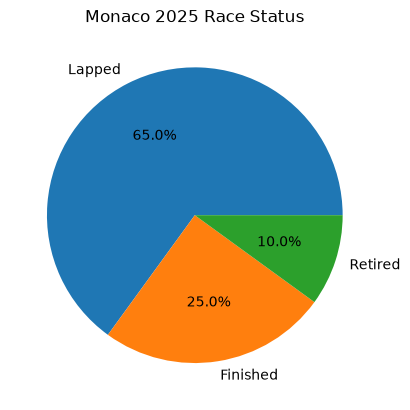

In [46]:
plt.pie(status_percentages,autopct="%1.1f%%",labels=status_percentages.index)

plt.title("Monaco 2025 Race Status")
plt.show()

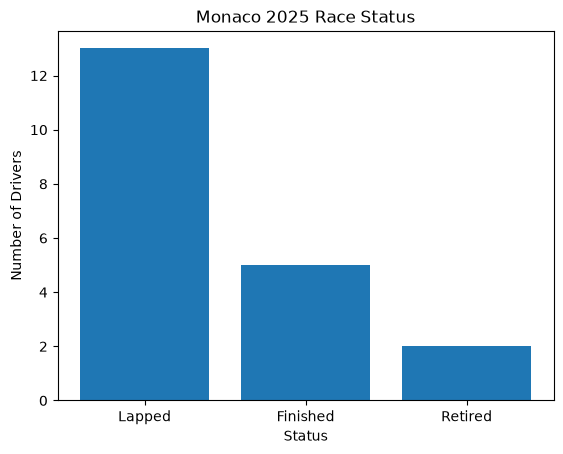

In [ ]:
plt.bar(status_counts.index, status_counts)

plt.title("Monaco 2025 Race Status")
plt.xlabel("Status")
plt.ylabel("Number of Drivers")
plt.xticks(rotation=0)
plt.show()

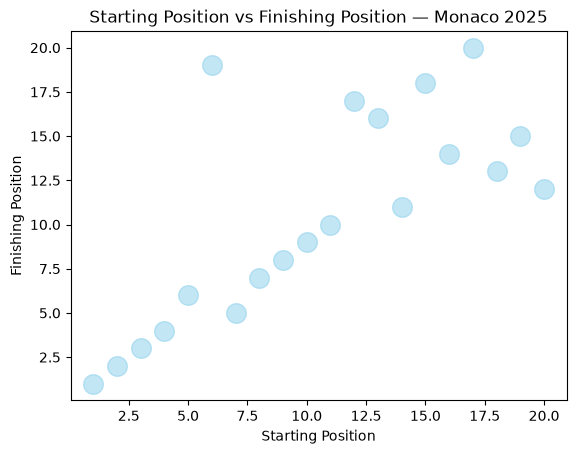

In [56]:
plt.scatter(
    results["GridPosition"],
    results["Position"], color='skyblue', alpha = 0.5, s=200
)

plt.xlabel("Starting Position")
plt.ylabel("Finishing Position")
plt.title("Starting Position vs Finishing Position — Monaco 2025")

plt.show()

In [57]:
correlation = results["GridPosition"].corr(results["Position"])

print(correlation)

0.7383458646616541


In [58]:
results_no_alonso = results[results["FullName"] != "Fernando Alonso"]

correlation_no_alonso = results_no_alonso["GridPosition"].corr(
    results_no_alonso["Position"]
)

print(correlation_no_alonso)

0.8628494539845182


In [59]:
results["Time"].dtype

dtype('<m8[ns]')

In [60]:
results[["FullName", "Position", "Time"]]

,FullName,Position,Time
4,Lando Norris,1.0,0 days 01:40:33.843000
16,Charles Leclerc,2.0,0 days 00:00:03.131000
81,Oscar Piastri,3.0,0 days 00:00:03.658000
1,Max Verstappen,4.0,0 days 00:00:20.572000
44,Lewis Hamilton,5.0,0 days 00:00:51.387000
6,Isack Hadjar,6.0,0 days 00:01:05.082000
31,Esteban Ocon,7.0,0 days 00:01:06.029000
30,Liam Lawson,8.0,0 days 00:01:06.746000
23,Alexander Albon,9.0,0 days 00:00:11.869000
55,Carlos Sainz,10.0,0 days 00:00:15.232000


In [66]:
classified = results[results["Status"] != "Retired"]

In [67]:
classified[["FullName", "Position", "Time"]]

,FullName,Position,Time
4,Lando Norris,1.0,0 days 01:40:33.843000
16,Charles Leclerc,2.0,0 days 00:00:03.131000
81,Oscar Piastri,3.0,0 days 00:00:03.658000
1,Max Verstappen,4.0,0 days 00:00:20.572000
44,Lewis Hamilton,5.0,0 days 00:00:51.387000
6,Isack Hadjar,6.0,0 days 00:01:05.082000
31,Esteban Ocon,7.0,0 days 00:01:06.029000
30,Liam Lawson,8.0,0 days 00:01:06.746000
23,Alexander Albon,9.0,0 days 00:00:11.869000
55,Carlos Sainz,10.0,0 days 00:00:15.232000


In [68]:
results[["FullName", "Position", "ClassifiedPosition", "Status", "Time"]]

,FullName,Position,ClassifiedPosition,Status,Time
4,Lando Norris,1.0,1,Finished,0 days 01:40:33.843000
16,Charles Leclerc,2.0,2,Finished,0 days 00:00:03.131000
81,Oscar Piastri,3.0,3,Finished,0 days 00:00:03.658000
1,Max Verstappen,4.0,4,Finished,0 days 00:00:20.572000
44,Lewis Hamilton,5.0,5,Finished,0 days 00:00:51.387000
6,Isack Hadjar,6.0,6,Lapped,0 days 00:01:05.082000
31,Esteban Ocon,7.0,7,Lapped,0 days 00:01:06.029000
30,Liam Lawson,8.0,8,Lapped,0 days 00:01:06.746000
23,Alexander Albon,9.0,9,Lapped,0 days 00:00:11.869000
55,Carlos Sainz,10.0,10,Lapped,0 days 00:00:15.232000


In [70]:
classified = results[results["ClassifiedPosition"] != "R"].copy()

classified["TimeGap"] = classified["Time"].dt.total_seconds()

classified.loc[classified["Position"] == 1, "TimeGap"] = 0

classified[["FullName", "Position", "TimeGap"]]

,FullName,Position,TimeGap
4,Lando Norris,1.0,0.000
16,Charles Leclerc,2.0,3.131
81,Oscar Piastri,3.0,3.658
1,Max Verstappen,4.0,20.572
44,Lewis Hamilton,5.0,51.387
6,Isack Hadjar,6.0,65.082
31,Esteban Ocon,7.0,66.029
30,Liam Lawson,8.0,66.746
23,Alexander Albon,9.0,11.869
55,Carlos Sainz,10.0,15.232


In [71]:
classified["Position"].corr(classified["TimeGap"])

np.float64(0.4989163995253456)